---
header-includes:
  - \usepackage{braket}
---

# Bloch Sphere Simulation & Visualization  
### Geometric Representation of a Single Qubit

In this notebook, we build the Bloch sphere representation of a qubit *from scratch*.  
The Bloch sphere is one of the most powerful tools in quantum information: it provides a complete geometric description of any pure qubit state using only two real parameters.

A pure qubit state  

$$\ket{\psi} = \alpha\ket0 + \beta\ket1 \quad, \quad |\alpha|^2 + |\beta|^2 = 1$$

can be mapped to a point on the unit sphere through the Bloch vector:

$$\vec{r} = \braket{\psi | \vec{\sigma} | \psi} = \big(\braket{\sigma_x},\braket{\sigma_y}, \braket{\sigma_z}\big).$$

This notebook has two goals:

1. **Tutorial goal:**  
   Understand deeply how the Bloch sphere emerges from the algebra of Pauli matrices and how to compute Bloch vectors numerically.

2. **Professional goal (for the M2 QC jury):**  
   Demonstrate the ability to connect theory → numerical simulation → visualization, which is essential in quantum computing research.

We will:

- define the computational basis and Pauli matrices  
- implement a function that converts a state vector into its Bloch vector  
- verify the mapping on standard states  
- prepare the ground for full Bloch sphere visualization (next sections)

___

---
header-includes:
  - \usepackage{braket}
---

## 1. Imports & Basic Definitions

We begin by importing NumPy for linear algebra and defining the standard objects of a qubit:

- the computational basis states $\ket0$ and $\ket1$.  
- the Pauli matrices $\sigma_x$, $\sigma_y$, $\sigma_z$. 

These matrices form a basis for all 2×2 Hermitian operators and define the x, y, z axes of the Bloch sphere.  
They will be used to compute expectation values and Bloch vectors.


In [8]:
import numpy as np

# ---------------------------------------------------------
# Computational basis states
# ---------------------------------------------------------
# |0> = (1, 0)^T
# |1> = (0, 1)^T
# We store them as column vectors (2x1 arrays)
ket_0 = np.array([[1],
                  [0]], dtype=complex)

ket_1 = np.array([[0],
                  [1]], dtype=complex)

# ---------------------------------------------------------
# Pauli matrices
# ---------------------------------------------------------
# These matrices generate SU(2) and correspond to the
# x, y, z axes of the Bloch sphere.
sigma_x = np.array([[0, 1],
                    [1, 0]], dtype=complex)

sigma_y = np.array([[0, -1j],
                    [1j,  0]], dtype=complex)

sigma_z = np.array([[1,  0],
                    [0, -1]], dtype=complex)

# Identity matrix (useful later)
I2 = np.eye(2, dtype=complex)

print("Basis states and Pauli matrices loaded.")


Basis states and Pauli matrices loaded.


---
header-includes:
  - \usepackage{braket}
---

## 2. Converting a State Vector into a Bloch Vector

Any pure qubit state can be represented as a point on the Bloch sphere.  
Given a normalized state vector


$$\ket{\psi}= 
\begin{pmatrix}
\alpha \\ \beta
\end{pmatrix},
$$

the Bloch vector is defined as:

$$\vec{r} = 
\begin{pmatrix}
\braket{\sigma_x} \\
\braket{\sigma_y} \\
\braket{\sigma_z}
\end{pmatrix}
=
\begin{pmatrix}
\psi^\dagger \sigma_x \psi \\
\psi^\dagger \sigma_y \psi \\
\psi^\dagger \sigma_z \psi
\end{pmatrix}.
$$

This function computes these expectation values numerically.

Important notes:
- The state must be normalized.  
- The resulting vector must satisfy $|\vec{r}| = 1$ for pure states.  
- This mapping is the bridge between Hilbert space and 3D geometry.

___

In [9]:
def bloch_vector(psi):
    """
    Compute the Bloch vector of a pure qubit state |psi>.
    
    Parameters
    ----------
    psi : np.ndarray
        A 2x1 complex column vector representing the qubit state.
        Must be normalized (||psi|| = 1).
    
    Returns
    -------
    r : np.ndarray
        A 3-element real vector (rx, ry, rz) corresponding to:
        rx = <sigma_x>
        ry = <sigma_y>
        rz = <sigma_z>
    """

    # ---------------------------------------------------------
    # Expectation value formula:
    # <A> = psi^\dagger A psi
    # psi.conj().T is the bra <psi|
    # ---------------------------------------------------------

    # <sigma_x>
    rx = np.real(psi.conj().T @ sigma_x @ psi)[0, 0]

    # <sigma_y>
    ry = np.real(psi.conj().T @ sigma_y @ psi)[0, 0]

    # <sigma_z>
    rz = np.real(psi.conj().T @ sigma_z @ psi)[0, 0]

    # Return as a simple 1D vector
    return np.array([rx, ry, rz], dtype=float)


# ---------------------------------------------------------
# Test the function on |0> and |1>
# ---------------------------------------------------------
print("Bloch(|0>) =", bloch_vector(ket_0))  # should be (0,0,1)
print("Bloch(|1>) =", bloch_vector(ket_1))  # should be (0,0,-1)


Bloch(|0>) = [0. 0. 1.]
Bloch(|1>) = [ 0.  0. -1.]



---
header-includes:
  - \usepackage{braket}
---

## 3. Plotting the Bloch Sphere

The Bloch sphere is the geometric representation of all pure qubit states.  
Every state corresponds to a point on the unit sphere in $\mathbb{R}^3$, with coordinates:


$$\vec{r} = \big(\braket{\sigma_x},\braket{\sigma_y}, \braket{\sigma_z}\big).$$

To visualize this structure, we first draw:

- the **unit sphere** (surface of all pure states)  
- the **x, y, z axes** (defined by the Pauli matrices)  
- optional grid lines (meridians and parallels)  

This figure will serve as the base on which we will later plot:

- computational basis states  
- superposition states  
- arbitrary states  
- Bloch trajectories from Notebook 1  
- gate actions from Notebook 3  

The goal is to build a clean, readable, and professional Bloch sphere visualization.

---


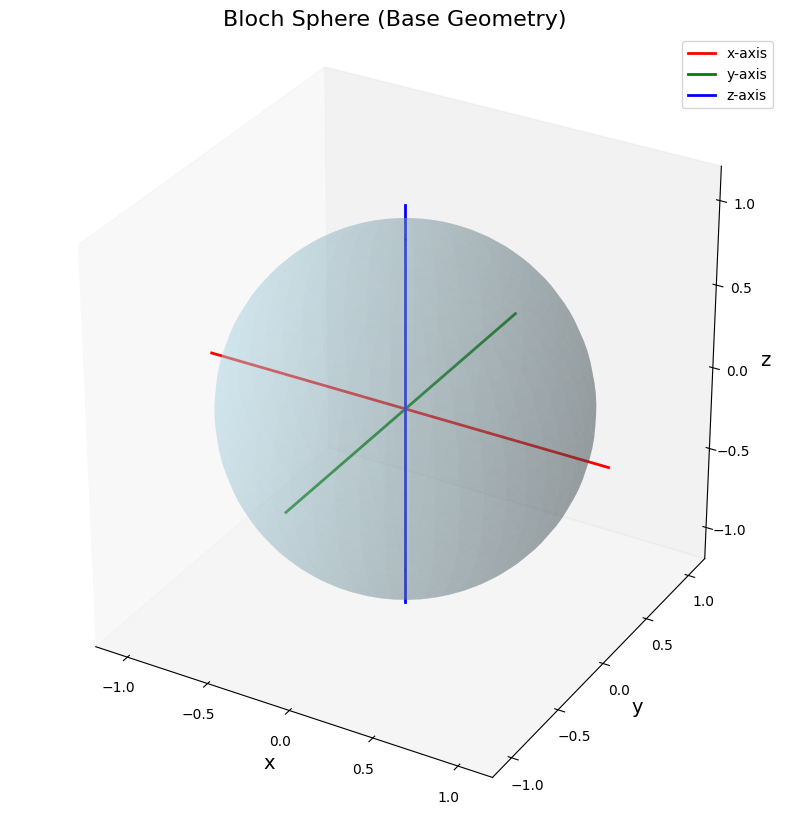

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

# ---------------------------------------------------------
# Create a 3D figure
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# ---------------------------------------------------------
# Generate the sphere surface
# ---------------------------------------------------------
# We use spherical coordinates:
#   x = sin(theta) cos(phi)
#   y = sin(theta) sin(phi)
#   z = cos(theta)
# where:
#   theta ∈ [0, π]   (polar angle)
#   phi   ∈ [0, 2π] (azimuthal angle)

theta = np.linspace(0, np.pi, 50)
phi   = np.linspace(0, 2*np.pi, 50)

theta, phi = np.meshgrid(theta, phi)

# Convert spherical → Cartesian coordinates
x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

# ---------------------------------------------------------
# Plot the sphere surface
# ---------------------------------------------------------
ax.plot_surface(
    x, y, z,
    rstride=1, cstride=1,
    color='lightblue',
    alpha=0.3,          # transparency
    linewidth=0
)

# ---------------------------------------------------------
# Plot the x, y, z axes
# ---------------------------------------------------------
# These correspond to the eigenstates of σ_x, σ_y, σ_z.
axis_length = 1.2

# x-axis (red)
ax.plot(
    [-axis_length, axis_length], [0, 0], [0, 0],
    color='red', linewidth=2, label='x-axis'
)

# y-axis (green)
ax.plot(
    [0, 0], [-axis_length, axis_length], [0, 0],
    color='green', linewidth=2, label='y-axis'
)

# z-axis (blue)
ax.plot(
    [0, 0], [0, 0], [-axis_length, axis_length],
    color='blue', linewidth=2, label='z-axis'
)

# ---------------------------------------------------------
# Cosmetic improvements
# ---------------------------------------------------------
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

ax.set_box_aspect([1, 1, 1])  # equal aspect ratio

ax.set_title("Bloch Sphere (Base Geometry)", fontsize=16)

# Remove background grid for a cleaner look
ax.grid(False)

# Show legend
ax.legend()

plt.show()
